### What is being measured?

Concretely, for each junior author:

`n_citing_papers_total_post_award`: number of papers that cite the award paper after it wins

`n_citing_papers_with_junior_author_post_award`: subset of those citing papers where the junior author is on the author list (self‑citations)

`share_self_citing` = `self_citing` / `total_citing`

So the main outcome is: *how much of the award paper’s later citation traffic comes from the junior author themselves?*
- The word "share" means the fraction of all post‑award citing papers that include the junior author as a coauthor.

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Use black-and-white style (like other analysis notebooks)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Greys_r')

BASE = Path(r'B:\Semester 4 UU\thesis-best-paper-trajectories')
DATA_DERIVED = BASE / 'data' / 'derived'
FIG_DIR = BASE / 'figures' / '32_junior_self_cites'
FIG_DIR.mkdir(parents=True, exist_ok=True)

PATH_SELF = DATA_DERIVED / 'junior_awardpaper_self_cites_summary.csv'

df = pd.read_csv(PATH_SELF)
print('Loaded self-citation summary:', df.shape)
df.head()

Loaded self-citation summary: (596, 9)


,award_paper_id,junior_author_id,n_citing_papers_with_junior_author_post_award,n_distinct_citing_papers_with_junior,award_year,award_conference,junior_author_name,n_citing_papers_total_post_award,share_self_citing
0,https://openalex.org/W108223363,https://openalex.org/A5089862531,0,23,2013,ICML,Roi Livni,23,0.0
1,https://openalex.org/W110738662,https://openalex.org/A5102785744,0,44,2007,IJCAI,Maleeha Qazi,44,0.0
2,https://openalex.org/W118378920,https://openalex.org/A5012667159,0,24,2006,SIGMOD,Timothy David Brody,24,0.0
3,https://openalex.org/W146360823,https://openalex.org/A5017775499,0,18,2004,OSDI,Paul Twohey,18,0.0
4,https://openalex.org/W146360823,https://openalex.org/A5056288677,0,18,2004,OSDI,Junfeng Yang,18,0.0


In [2]:
# Basic cleaning / sanity

df['award_conference'] = df['award_conference'].astype(str)
df['award_year'] = pd.to_numeric(df['award_year'], errors='coerce')

df['share_self_citing'] = df['share_self_citing'].fillna(0.0)
df['n_citing_papers_total_post_award'] = pd.to_numeric(
    df['n_citing_papers_total_post_award'], errors='coerce'
)
df = df[df['n_citing_papers_total_post_award'] > 0].copy()

print('After cleaning:', df.shape)
df.describe(include='all').T.head(12)

After cleaning: (596, 9)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
award_paper_id,596,463,https://openalex.org/W2116907335,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
junior_author_id,596,596,https://openalex.org/A5089862531,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_citing_papers_with_junior_author_post_award,596.0,NaN,NaN,NaN,3.149329,5.100949,0.0,0.0,1.0,4.0,45.0
n_distinct_citing_papers_with_junior,596.0,NaN,NaN,NaN,295.493289,1311.541294,1.0,46.0,102.0,203.25,28275.0
award_year,596.0,NaN,NaN,NaN,2011.493289,4.984509,2000.0,2008.0,2012.5,2016.0,2018.0
award_conference,596,30,CHI,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
junior_author_name,596,596,Roi Livni,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_citing_papers_total_post_award,596.0,NaN,NaN,NaN,295.493289,1311.541294,1.0,46.0,102.0,203.25,28275.0
share_self_citing,596.0,NaN,NaN,NaN,0.036377,0.068801,0.0,0.0,0.008033,0.046067,0.5


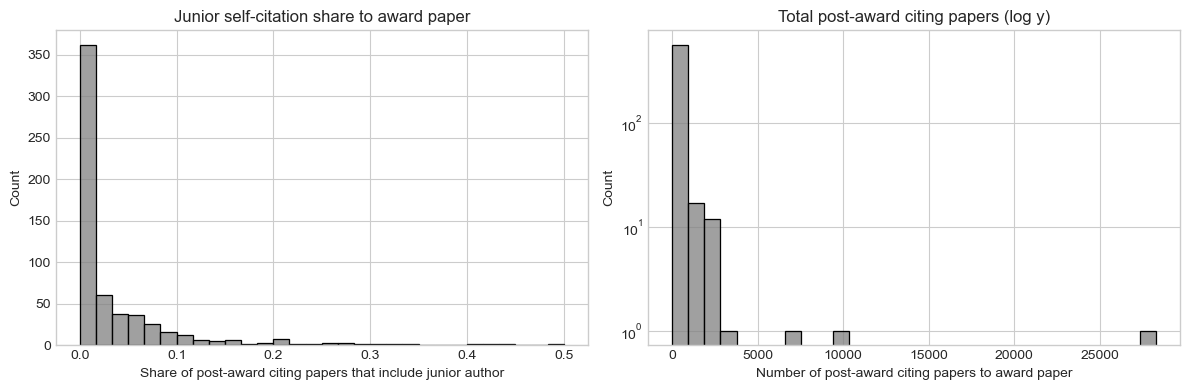

In [4]:
# 1. Overall distribution of junior self-citation share

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: distribution of self-citation share
sns.histplot(df['share_self_citing'], bins=30, ax=axes[0],
             color='0.5', edgecolor='black')
axes[0].set_title('Junior self-citation share to award paper')
axes[0].set_xlabel(
    'Share of post-award citing papers that include junior author'
)

# right: distribution of total post-award citing papers (log y)
sns.histplot(df['n_citing_papers_total_post_award'], bins=30, ax=axes[1],
             color='0.5', edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Total post-award citing papers (log y)')
axes[1].set_xlabel('Number of post-award citing papers to award paper')

plt.tight_layout()
fig.savefig(FIG_DIR / '32_selfcite_overall_histograms.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# 2. Junior self-citation share by conference: summary table

conf_stats = (
    df.groupby('award_conference', as_index=False)
      .agg(
          n_junior_authors=('junior_author_id', 'count'),
          mean_share=('share_self_citing', 'mean'),
          median_share=('share_self_citing', 'median')
      )
      .sort_values('mean_share', ascending=False)
)

conf_stats.head(15)

,award_conference,n_junior_authors,mean_share,median_share
18,PODS,12,0.154467,0.101085
0,AAAI,14,0.086375,0.033243
28,VLDB,18,0.071044,0.028034
5,FOCS,9,0.068472,0.016216
26,STOC,10,0.064284,0.025517
11,INFOCOM,16,0.060908,0.008309
3,CIKM,12,0.060382,0.060754
17,PLDI,26,0.058147,0.018250
24,SODA,5,0.053371,0.016129
9,ICSE,80,0.042038,0.012692


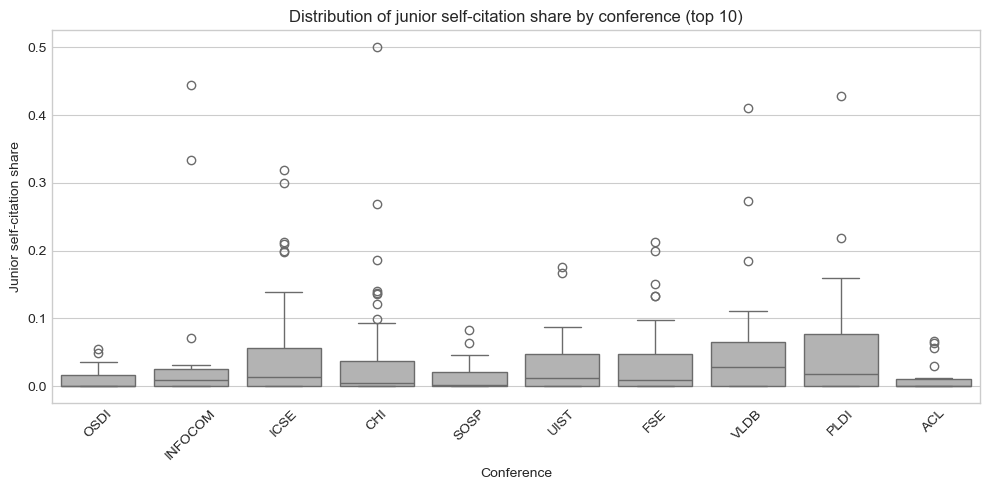

In [7]:
# 2. Junior self-citation share by conference: boxplot (top 10)

top_confs = df['award_conference'].value_counts().head(10).index
df_top = df[df['award_conference'].isin(top_confs)].copy()

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_top,
    x='award_conference',
    y='share_self_citing',
    color='0.7'  # light grey fill
)
plt.xticks(rotation=45)
plt.ylabel('Junior self-citation share')
plt.xlabel('Conference')
plt.title('Distribution of junior self-citation share by conference (top 10)')
plt.tight_layout()
plt.savefig(FIG_DIR / '32_selfcite_by_conference_boxplot.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# 3. Junior self-citation share over award year: summary table

year_stats = (
    df.groupby('award_year', as_index=False)
      .agg(
          mean_share=('share_self_citing', 'mean'),
          median_share=('share_self_citing', 'median'),
          n_junior_authors=('junior_author_id', 'count')
      )
)

year_stats.head()

,award_year,mean_share,median_share,n_junior_authors
0,2000,0.007244,0.001622,10
1,2001,0.013571,0.000000,14
2,2002,0.013703,0.008671,3
3,2003,0.020808,0.007246,21
4,2004,0.033913,0.006217,26


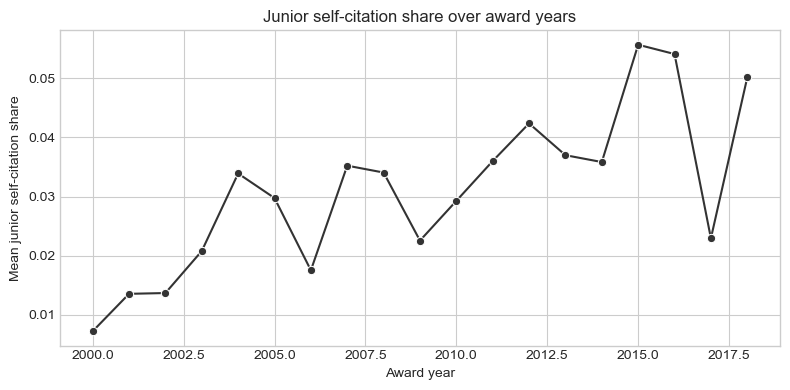

In [9]:
# 3. Junior self-citation share over award year: line plot

plt.figure(figsize=(8, 4))
sns.lineplot(data=year_stats, x='award_year', y='mean_share',
             color='0.2', marker='o')
plt.ylabel('Mean junior self-citation share')
plt.xlabel('Award year')
plt.title('Junior self-citation share over award years')
plt.tight_layout()
plt.savefig(FIG_DIR / '32_selfcite_over_time_mean.png',
            dpi=300, bbox_inches='tight')
plt.show()

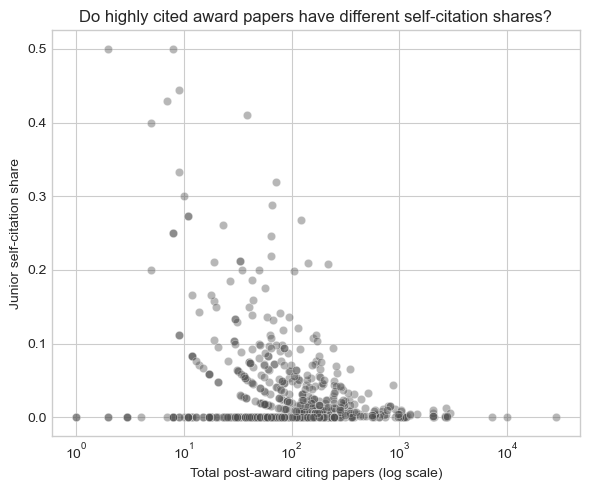

In [10]:
# 4. Relationship between self-citation share and citation impact size

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x='n_citing_papers_total_post_award',
    y='share_self_citing',
    color='0.3',
    alpha=0.4,
)
plt.xscale('log')
plt.xlabel('Total post-award citing papers (log scale)')
plt.ylabel('Junior self-citation share')
plt.title('Do highly cited award papers have different self-citation shares?')
plt.tight_layout()
plt.savefig(FIG_DIR / '32_selfcite_vs_total_citations_scatter.png',
            dpi=300, bbox_inches='tight')
plt.show()

Summary:

The average share of self‑citations is about 3.6%.

The median is around 0.8%.

The 75th percentile is about 4.6%, and the maximum is 50%.

*It shows that junior authors’ self‑citations to their best‑paper award articles are usually a very small fraction of total post‑award citations, with modest venue‑level differences and a long but sparse right tail.*